##Reto modulo 2 Pamela Hernández

In [57]:
from sklearn import cluster, metrics
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, Normalizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [79]:
data = pd.read_csv("train.csv")
data.head()

,Employee_ID,Gender,Age,Education_Level,Relationship_Status,Hometown,Unit,Decision_skill_possess,Time_of_service,Time_since_promotion,...,Compensation_and_Benefits,Work_Life_balance,VAR1,VAR2,VAR3,VAR4,VAR5,VAR6,VAR7,Attrition_rate
0,EID_23371,F,42.0,4,Married,Franklin,IT,Conceptual,4.0,4,...,type2,3.0,4,0.7516,1.8688,2.0,4,5,3,0.1841
1,EID_18000,M,24.0,3,Single,Springfield,Logistics,Analytical,5.0,4,...,type2,4.0,3,-0.9612,-0.4537,2.0,3,5,3,0.0670
2,EID_3891,F,58.0,3,Married,Clinton,Quality,Conceptual,27.0,3,...,type2,1.0,4,-0.9612,-0.4537,3.0,3,8,3,0.0851
3,EID_17492,F,26.0,3,Single,Lebanon,Human Resource Management,Behavioral,4.0,3,...,type2,1.0,3,-1.8176,-0.4537,NaN,3,7,3,0.0668
4,EID_22534,F,31.0,1,Married,Springfield,Logistics,Conceptual,5.0,4,...,type3,3.0,1,0.7516,-0.4537,2.0,2,8,2,0.1827


In [80]:
#Borrar columnas no necesarias, las VAR no conozco a que se refieren por eso la borro
df = data.drop(["VAR1",	"VAR2",	"VAR3",	"VAR4",	"VAR5",	"VAR6",	"VAR7","Employee_ID" ], axis=1)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gender                     7000 non-null   object 
 1   Age                        6588 non-null   float64
 2   Education_Level            7000 non-null   int64  
 3   Relationship_Status        7000 non-null   object 
 4   Hometown                   7000 non-null   object 
 5   Unit                       7000 non-null   object 
 6   Decision_skill_possess     7000 non-null   object 
 7   Time_of_service            6856 non-null   float64
 8   Time_since_promotion       7000 non-null   int64  
 9   growth_rate                7000 non-null   int64  
 10  Travel_Rate                7000 non-null   int64  
 11  Post_Level                 7000 non-null   int64  
 12  Pay_Scale                  6991 non-null   float64
 13  Compensation_and_Benefits  7000 non-null   objec

In [82]:
#Imputamos las variables que tienen datos nulos con el promedio
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Time_of_service'].fillna(df['Time_of_service'].median(), inplace=True)
df['Pay_Scale'].fillna(df['Pay_Scale'].median(), inplace=True)
df['Work_Life_balance'].fillna(df['Work_Life_balance'].median(), inplace=True)

C:\Users\iphernandez\AppData\Local\Temp\ipykernel_37904\1464426798.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\iphernandez\AppData\Local\Temp\ipykernel_37904\1464426798.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gender                     7000 non-null   object 
 1   Age                        7000 non-null   float64
 2   Education_Level            7000 non-null   int64  
 3   Relationship_Status        7000 non-null   object 
 4   Hometown                   7000 non-null   object 
 5   Unit                       7000 non-null   object 
 6   Decision_skill_possess     7000 non-null   object 
 7   Time_of_service            7000 non-null   float64
 8   Time_since_promotion       7000 non-null   int64  
 9   growth_rate                7000 non-null   int64  
 10  Travel_Rate                7000 non-null   int64  
 11  Post_Level                 7000 non-null   int64  
 12  Pay_Scale                  7000 non-null   float64
 13  Compensation_and_Benefits  7000 non-null   objec

Agrupamos datos

In [84]:
# Transformamos las columnas que no son tipo objeto y dejamos en una matriz númerica.
df2 = df.copy()
for col in df2.columns:
    if df2[col].dtype == 'object':
        df2[col] = OrdinalEncoder().fit_transform(df2[[col]])
X_train = df2.to_numpy()
print(X_train)

[[ 0.     42.      4.     ...  2.      3.      0.1841]
 [ 1.     24.      3.     ...  2.      4.      0.067 ]
 [ 0.     58.      3.     ...  2.      1.      0.0851]
 ...
 [ 0.     49.      3.     ...  2.      4.      0.7847]
 [ 0.     47.      3.     ...  0.      2.      0.4162]
 [ 0.     58.      3.     ...  2.      3.      0.091 ]]


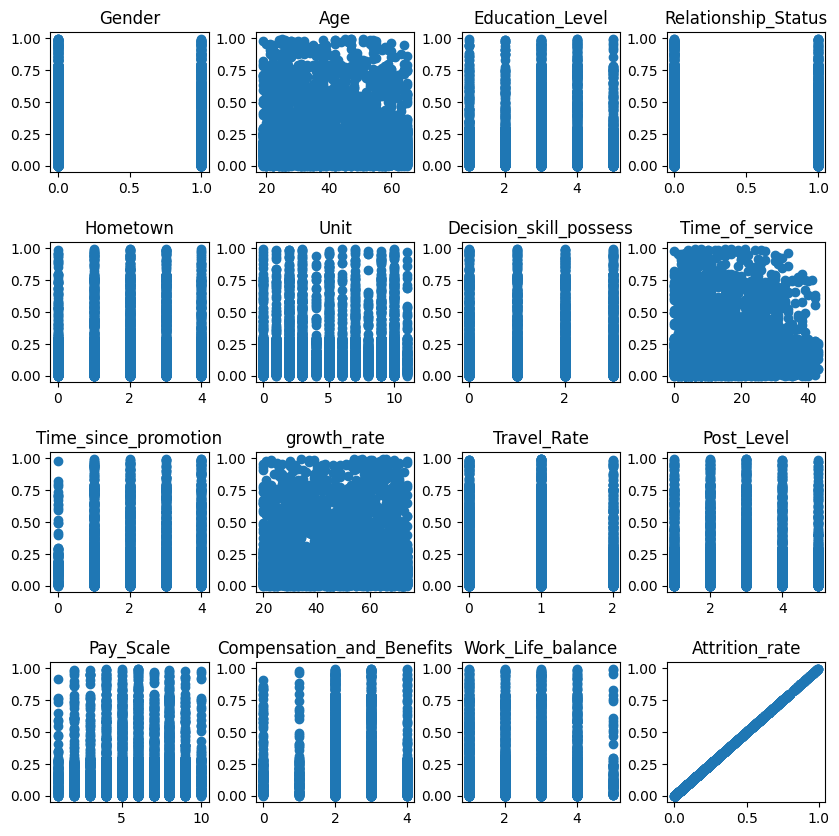

In [85]:
df3= df2.copy()
v = 0
fig, axs = plt.subplots(4, 4, figsize=(10, 10))
for i in range(4):
  for j in range(4):
    axs[i,j].scatter(X_train[:,v], X_train[:,15])
    axs[i,j].set_title(df3.columns[v])
    #axs[i,j].set_ylim([0,0.5e7])
    v+=1
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

In [86]:
#Codigo de agrupamiento de datos, es para usar el indice y los datos deben de estar agrupados,
#la variable y2 es donde estan los grupos asignados y se evalua  si nuevas etiquetas cumplen con propiedades de compacidad y separacion que mide.
from sklearn import cluster
Xp = StandardScaler().fit_transform(X_train)
k_means = cluster.KMeans(n_clusters=2).fit(Xp)
y2 = k_means.predict(Xp) 

In [87]:
#Codigo de implementación de datos, primero importar la implementación y llamarlo, 
# se ponen datos originales y las nuevas etiquetas y devuelve el valor que dice la calidad del agrupamiento.
from sklearn.metrics import silhouette_score
idx_2 = silhouette_score(Xp, y2)
idx_2

0.09031794777509981

In [88]:
k_means = cluster.KMeans(n_clusters=3).fit(Xp)
y3 = k_means.predict(Xp)
idx_3 = silhouette_score(Xp, y3)
idx_3  #como el valor es menor que el de idx_2 es mejor agrupar en 2 que en tres grupos

0.06059736634115372

In [89]:
k_means = cluster.KMeans(n_clusters=4).fit(Xp)
y4 = k_means.predict(Xp)
idx_4 = silhouette_score(Xp, y4)
idx_4 

0.07363495716202562

##Número de agrupaciones con K-Elbow e Índice Silhouette y Calinski Harabasz

In [90]:
#Estandarización de datos
np.random.seed(0)
X = StandardScaler().fit_transform(X_train)

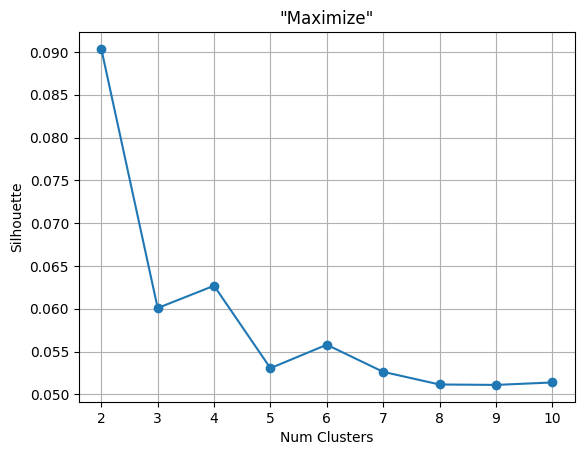

In [91]:
# Construimos gráfica K-Elbow para saber el número de grupos que conviene.
nc = 11  # Para 12 grupos, que hasta ahí llegue.
results = {}
for k in range(2, nc):
  k_means = cluster.KMeans(n_clusters=k).fit(X)
  y_pred = k_means.predict(X)
  results[k] = metrics.silhouette_score(X, y_pred)

clusters_counts = list(results.keys())
index_values = list(results.values())

plt.plot(clusters_counts, index_values, 'o-')
plt.grid(True)
plt.title('"Maximize"')
plt.xlabel('Num Clusters')
plt.xticks(clusters_counts)
plt.ylabel('Silhouette')
plt.show()

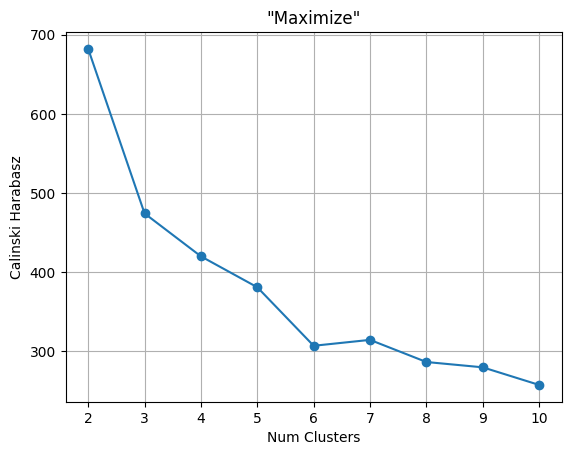

In [92]:
nc = 11
y_preds = []
results = {}
for k in range(2, nc):
  k_means = cluster.KMeans(n_clusters=k).fit(X)
  y_pred = k_means.predict(X)
  y_preds.append(y_pred)
  results[k] = metrics.calinski_harabasz_score(X, y_pred)

clusters_counts = list(results.keys())
index_values = list(results.values())

plt.plot(clusters_counts, index_values, 'o-')
plt.grid(True)
plt.title('"Maximize"')
plt.xlabel('Num Clusters')
plt.xticks(clusters_counts)
plt.ylabel('Calinski Harabasz')
plt.show()

La gráfica Silhouette propone 4 grupos, mientras que eb Calinski son 6.

In [72]:
f = 7
t = 'time_of_service'

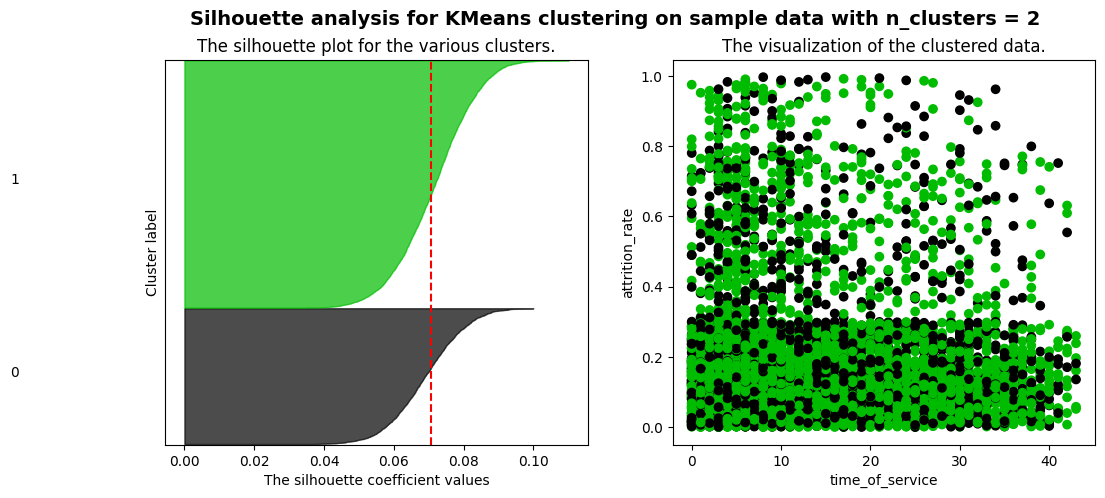

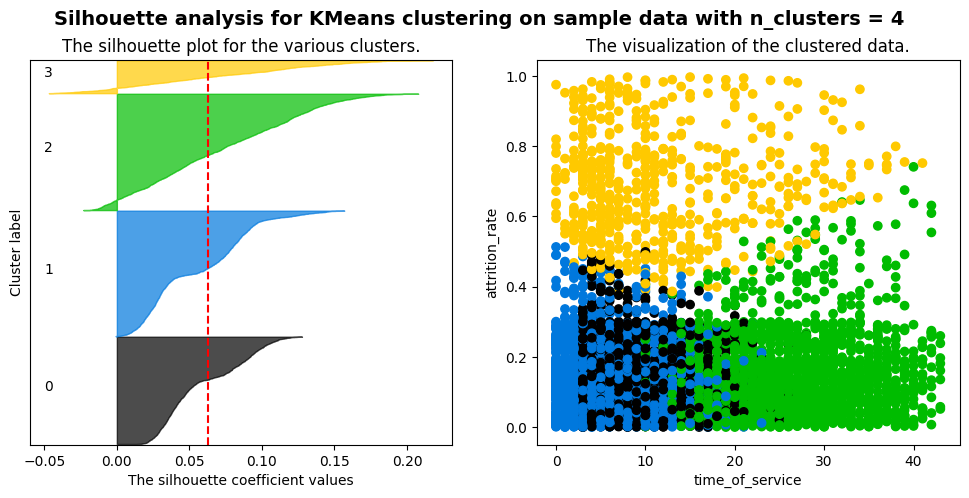

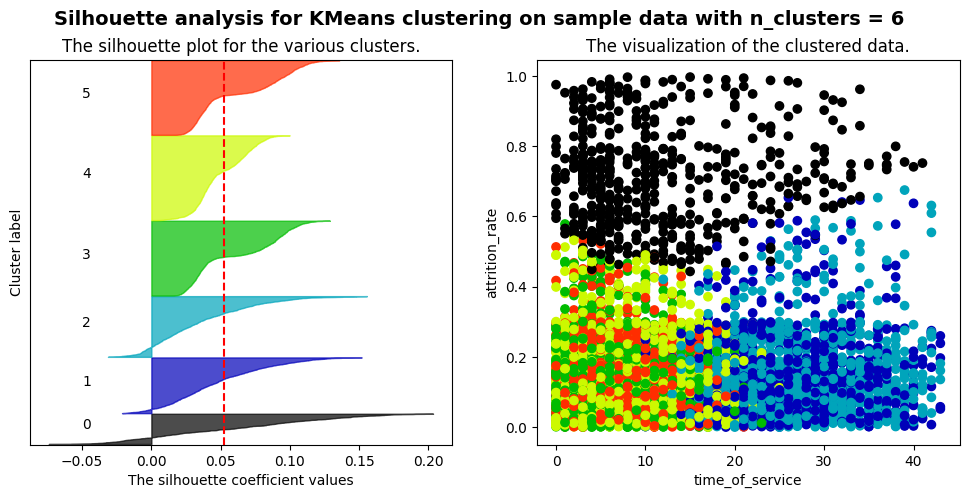

In [ ]:
#basandonos en la variable time_of_service
import matplotlib.cm as cm
for k in [2, 4, 6]:
  fig, (ax0, ax1) = plt.subplots(1, 2)
  fig.set_size_inches(12, 5)
  # The (k+1)*10 is for inserting blank space between silhouette
  # plots of individual clusters, to demarcate them clearly.
  ax0.set_ylim([0, len(X) + (k + 1) * 10])
  k_means = cluster.KMeans(n_clusters=k)
  y_pred = k_means.fit_predict(X)
  silhouette_avg = metrics.silhouette_score(X, y_pred)
  sample_silhouette_values = metrics.silhouette_samples(X, y_pred)
  y_lower = 10
  for i in range(k):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = \
        sample_silhouette_values[y_pred == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / k)
    ax0.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    # Label the silhouette plots with their cluster numbers at the middle
    ax0.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples
  ax0.set_title("The silhouette plot for the various clusters.")
  ax0.set_xlabel("The silhouette coefficient values")
  ax0.set_ylabel("Cluster label")
  ax0.set_yticks([])  # Clear the yaxis labels / ticks
  # The vertical line for average silhouette score of all the values
  ax0.axvline(x=silhouette_avg, color="red", linestyle="--")
  # 2nd Plot showing the actual clusters formed
  colors = cm.nipy_spectral(y_pred.astype(float) / k)
  ax1.scatter(X_train[:, f], X_train[:, 15], c=colors)
  #ax1.set_ylim(0, 0.5e7)
  ax1.set_title("The visualization of the clustered data.")
  ax1.set_xlabel(t)
  ax1.set_ylabel('attrition_rate')
  plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                "with n_clusters = %d" % k),
                fontsize=14, fontweight='bold')
plt.show()

 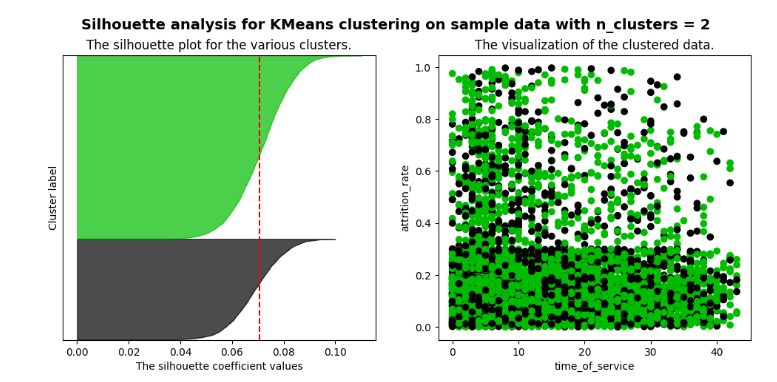 Para la primer gráfica se observanlos dos grupos y el grupo 1 con mayoria de datos, aunque se aprecia que no estan bien definidos ya se interponen entre si.

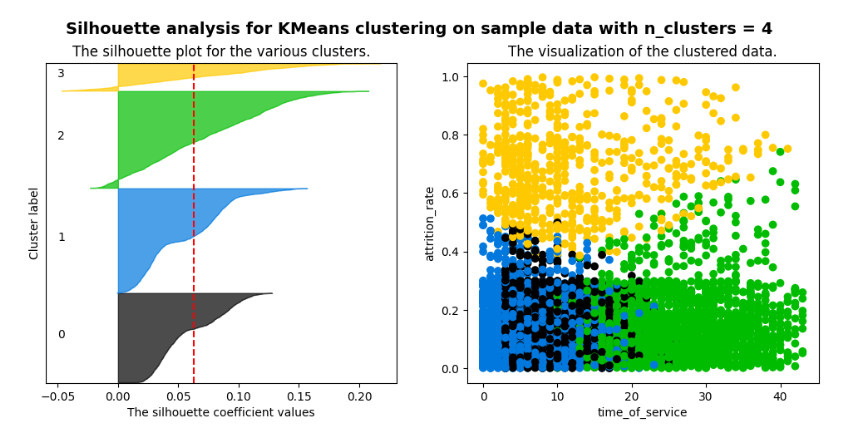 las grádicas 2, muestran 2 grupos bien definidos el 3 y 2. Además el indice de silhoute es mas alto que para solo los 2 grupos.

Y para el grupo de 6 que fue el que sugirio calinski solo el grupo 0 esta bien definido.

#General

In [93]:
# Se trabajará con 4 grupos tomando de referencia la gráfica de Silhouette 
# que es donde se aprecia mejor los grupos en que nos conviene agrupar.
k = 4  
k_means = cluster.KMeans(n_clusters=k)
y_pred1 = k_means.fit_predict(X)

In [94]:
# Arreglos de nuestros grupos.
y_pred1

array([2, 0, 3, ..., 0, 3, 3])

In [95]:
# Asigna cada elemento a un grupo en una nueva columna.
df['groups'] = y_pred1
grupodesercion = []
for g in range(k):
  grupodesercion.append(df[df['groups']==g])

In [96]:
# Cuantas personas hay en cada grupo.
for g in range(k):
    print('Grupo'+str(g),'tiene',len(grupodesercion[g]),'personas.')

Grupo0 tiene 1804 personas.
Grupo1 tiene 1714 personas.
Grupo2 tiene 1480 personas.
Grupo3 tiene 2002 personas.


##segmentación con el promedio de las variables de cada grupo

In [98]:
# Calculamos los centroides sobre los datos originales, los promedios de cada variable en cada grupo.
grouped = pd.DataFrame()
grouped['Features'] = df.columns[:-1]
for g in range(k):
    row = []
    for col in grouped['Features']:
        if grupodesercion[g][col].dtype != 'object':
            row.append(np.round(grupodesercion[g][col].mean(),2))
        else:
            row.append(grupodesercion[g][col].value_counts().keys()[0])
    grouped['Grupo'+str(g)] = row
grouped

,Features,Grupo0,Grupo1,Grupo2,Grupo3
0,Gender,F,F,F,F
1,Age,33.09,31.09,34.57,56.01
2,Education_Level,3.19,3.2,3.19,3.17
3,Relationship_Status,Single,Married,Married,Married
4,Hometown,Lebanon,Lebanon,Lebanon,Lebanon
5,Unit,IT,IT,IT,IT
6,Decision_skill_possess,Analytical,Conceptual,Analytical,Directive
7,Time_of_service,8.05,6.67,9.07,26.89
8,Time_since_promotion,2.31,1.39,3.47,2.44
9,growth_rate,47.22,47.08,46.95,47.0


Se puede observar que el grupo con mayor tasa de deserción es el Grupo1 con 0.20, es el grupo con la edad promedio menor, tienen menor tiempo de servicio, la edad y el poco tiempo en la compañía es indicio de que siguen buscando mejores oportunidades, su escala de pago es relativamente mas baja junto con el grupo 2, pero ellos al ser más jovenes salen a buscar otros empleos donde posiblemente les paguen mejor. Ademas son las que tienen menor tiempo desde una promocion por lo que eso dice que buscan rapido otras oportunidades. Algo en comun es que en todos los grupos predomina las mujeres, área de IT y el lugar de rsidencia es Lebanon.

In [104]:
dfg = grouped.transpose()
dfg.columns = dfg.loc['Features']
dfg = dfg.drop('Features')
dfg = dfg[dfg.columns[0:15]]
dfg

Features,Gender,Age,Education_Level,Relationship_Status,Hometown,Unit,Decision_skill_possess,Time_of_service,Time_since_promotion,growth_rate,Travel_Rate,Post_Level,Pay_Scale,Compensation_and_Benefits,Work_Life_balance
Grupo0,F,33.09,3.19,Single,Lebanon,IT,Analytical,8.05,2.31,47.22,0.82,2.84,6.01,type2,2.4
Grupo1,F,31.09,3.2,Married,Lebanon,IT,Conceptual,6.67,1.39,47.08,0.81,2.78,5.95,type2,2.41
Grupo2,F,34.57,3.19,Married,Lebanon,IT,Analytical,9.07,3.47,46.95,0.82,2.77,5.94,type2,2.38
Grupo3,F,56.01,3.17,Married,Lebanon,IT,Directive,26.89,2.44,47.0,0.82,2.79,6.1,type2,2.37


In [108]:
dfg1 = dfg[['Age','Education_Level','Time_of_service','Time_since_promotion','growth_rate','Travel_Rate','Post_Level','Pay_Scale','Work_Life_balance']]

In [109]:
import plotly.graph_objects as go
Xt = StandardScaler().fit_transform(dfg1.to_numpy())
Xt = Xt + abs(np.min(Xt))
fig = go.Figure()
for j in range(len(dfg1)):
  fig.add_trace(go.Bar(
      y=Xt[j,:],
      x=dfg.columns,
      name='Group '+str(j)
  ))
fig.update_layout(
    title='Variable mean per group',
    yaxis_title='normalized values',
    margin=dict(l=50, r=50, t=50, b=50)
)
fig.show()